# 23 -- Context vs. performance: descriptive check only

**Scope, stated up front**: this is NOT the context-conditional fusion
weighting the project's design notes describe ("context as fusion
weights, not identity features"). That mechanism needs many sessions per
person under varied, ideally repeated context conditions to be learnable
at all -- with ~12-17 participants and mostly ONE probe session each,
context and identity are almost perfectly confounded: there is no
within-person variation to learn a context effect FROM. Building a
learned weighting scheme on this data would look rigorous and be
statistically meaningless.

**What this notebook does instead**: asks whether self-reported context
CHANGE between a participant's own enrol and probe sessions correlates
with their own enrol->probe shift magnitude (already computed and
exported by nb13) or their own verification AUC (already computed and
exported by nb21/Gate 3). This generalises the pattern already found
anecdotally for two flagged participants -- `pAFQRTM`'s hand-use change,
`pUNKH7L`'s thin session -- into a systematic check across the WHOLE
evaluable cohort, rather than two hand-picked examples.

**Read every result here as exploratory, not confirmatory.** With ~12-17
data points, any correlation coefficient has enormous uncertainty. This
notebook reports patterns worth mentioning as observations, not
statistically validated findings -- and says so again at the point each
number appears, not just here.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats

%config InlineBackend.close_figures = False
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 60)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})

def find(*cands):
    for c in cands:
        if Path(c).exists(): return c
    raise FileNotFoundError(cands)

MOD_DIR = Path(find('data/processed/modelling', '../data/processed/modelling', '.'))
DATA_DIR = MOD_DIR.parent
OUT_DIR = DATA_DIR / 'context_analysis'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = OUT_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)

splits = pd.read_csv(find(str(MOD_DIR / 'identity_splits.csv'), 'identity_splits.csv'))

ctx_cols = ['ctxTimeOfDay', 'ctxFatigue', 'ctxFocusLevel', 'ctxEnvironmentNoise', 'ctxMovement',
            'ctxPosture', 'ctxHandUse', 'ctxInputDevice', 'ctxCaffeine', 'ctxAlcohol', 'ctxPrivacy']
raw_path = find(str(DATA_DIR / 'raw_events.parquet'), 'raw_events.parquet')
raw_ctx = pd.read_parquet(raw_path, columns=['sessionId', 'participantId'] + ctx_cols)
sess_ctx = raw_ctx.groupby(['participantId', 'sessionId']).first().reset_index()
print(f"{len(sess_ctx)} sessions with context data, {sess_ctx['participantId'].nunique()} participants")


96 sessions with context data, 18 participants


## 1. Enrol vs. probe context, per evaluable participant

Only participants with both an enrol and a probe session (the same set
nb13's shift-magnitude export covers) can be included -- everyone else
has no "change" to measure.


In [2]:
rows = []
for pid in splits['participantId'].unique():
    e_sess = splits[(splits['participantId']==pid) & (splits['role']=='enrol')]['sessionId']
    p_sess = splits[(splits['participantId']==pid) & (splits['role']=='probe')]['sessionId']
    if e_sess.empty or p_sess.empty:
        continue
    e_ctx = sess_ctx[sess_ctx['sessionId'] == e_sess.iloc[0]]
    p_ctx = sess_ctx[sess_ctx['sessionId'] == p_sess.iloc[0]]
    if e_ctx.empty or p_ctx.empty:
        continue
    e_row, p_row = e_ctx.iloc[0], p_ctx.iloc[0]

    row = {'participantId': pid}
    row['handuse_changed'] = int(e_row['ctxHandUse'] != p_row['ctxHandUse'])
    row['posture_changed'] = int(e_row['ctxPosture'] != p_row['ctxPosture'])
    row['movement_changed'] = int(e_row['ctxMovement'] != p_row['ctxMovement'])
    row['timeofday_changed'] = int(e_row['ctxTimeOfDay'] != p_row['ctxTimeOfDay'])
    try:
        row['fatigue_delta'] = float(p_row['ctxFatigue']) - float(e_row['ctxFatigue'])
    except (TypeError, ValueError):
        row['fatigue_delta'] = np.nan
    try:
        row['focus_delta'] = float(p_row['ctxFocusLevel']) - float(e_row['ctxFocusLevel'])
    except (TypeError, ValueError):
        row['focus_delta'] = np.nan
    row['n_context_fields_changed'] = (row['handuse_changed'] + row['posture_changed'] +
                                        row['movement_changed'] + row['timeofday_changed'])
    rows.append(row)

context_change_df = pd.DataFrame(rows)
print(f"{len(context_change_df)} evaluable participants with enrol+probe context data")
print(context_change_df.to_string(index=False))


12 evaluable participants with enrol+probe context data
participantId  handuse_changed  posture_changed  movement_changed  timeofday_changed  fatigue_delta  focus_delta  n_context_fields_changed
      p3M6E7Z                0                0                 0                  0            0.0          0.0                         0
      p3YDMHG                0                0                 0                  0            0.0          0.0                         0
      p95MPVX                0                1                 0                  1            1.0         -1.0                         2
      pA6XL23                0                0                 0                  1           -3.0          1.0                         1
      pAFQRTM                0                0                 0                  0            0.0          0.0                         0
      pEAB9GS                0                0                 0                  0           -2.0         -1

## 2. Join with shift magnitude (from nb13's export) and AUC (from Gate 3's export)

In [3]:
shift_mag_path = DATA_DIR / 'anomalous_diagnostic' / 'all_identities_shift_magnitude.csv'
gate3_pid_auc_path = DATA_DIR / 'gate3_device_evaluation' / 'gate3_per_participant_auc.csv'

if shift_mag_path.exists():
    shift_mag = pd.read_csv(shift_mag_path)
    context_change_df = context_change_df.merge(shift_mag, on='participantId', how='left')
    print(f"Joined shift_magnitude for {context_change_df['shift_magnitude'].notna().sum()} participants")
else:
    print(f"WARNING: {shift_mag_path} not found -- run nb13's export first")

if gate3_pid_auc_path.exists():
    pid_auc = pd.read_csv(gate3_pid_auc_path)[['participantId', 'auc']]
    context_change_df = context_change_df.merge(pid_auc, on='participantId', how='left')
    print(f"Joined verification auc for {context_change_df['auc'].notna().sum()} participants")
else:
    print(f"WARNING: {gate3_pid_auc_path} not found -- run nb21's Gate 3 export first")

print()
print(context_change_df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))
context_change_df.to_csv(OUT_DIR / 'context_change_vs_performance.csv', index=False)


Joined shift_magnitude for 12 participants
Joined verification auc for 12 participants

participantId  handuse_changed  posture_changed  movement_changed  timeofday_changed  fatigue_delta  focus_delta  n_context_fields_changed  shift_magnitude   auc
      p3M6E7Z                0                0                 0                  0          0.000        0.000                         0            3.185 1.000
      p3YDMHG                0                0                 0                  0          0.000        0.000                         0            3.533 1.000
      p95MPVX                0                1                 0                  1          1.000       -1.000                         2            1.950 1.000
      pA6XL23                0                0                 0                  1         -3.000        1.000                         1            2.371 1.000
      pAFQRTM                0                0                 0                  0          0.000   

## 3. Does ANY context change correlate with shift magnitude?

Small-N caveat restated: with this few data points, treat every
correlation below as a descriptive observation, not a statistically
validated effect. A single outlier participant can swing these numbers
substantially.


In [4]:
if 'shift_magnitude' in context_change_df.columns and context_change_df['shift_magnitude'].notna().sum() >= 4:
    print(f"n = {context_change_df['shift_magnitude'].notna().sum()} -- Spearman correlations "
          f"with shift_magnitude (small-N, descriptive only):\n")
    for col in ['handuse_changed', 'posture_changed', 'movement_changed', 'timeofday_changed',
                'n_context_fields_changed', 'fatigue_delta', 'focus_delta']:
        sub = context_change_df[[col, 'shift_magnitude']].dropna()
        if len(sub) < 4 or sub[col].nunique() < 2:
            print(f"  {col:24s}: insufficient variation to correlate (n={len(sub)}, "
                  f"unique values={sub[col].nunique() if len(sub) else 0})")
            continue
        rho, p = stats.spearmanr(sub[col], sub['shift_magnitude'])
        print(f"  {col:24s}: rho={rho:+.2f}, p={p:.3f}  (n={len(sub)})")
else:
    print("Not enough joined data to correlate -- check Section 2's warnings above.")


n = 12 -- Spearman correlations with shift_magnitude (small-N, descriptive only):

  handuse_changed         : insufficient variation to correlate (n=12, unique values=1)
  posture_changed         : rho=-0.48, p=0.114  (n=12)
  movement_changed        : rho=-0.04, p=0.893  (n=12)
  timeofday_changed       : rho=-0.36, p=0.247  (n=12)
  n_context_fields_changed: rho=-0.42, p=0.179  (n=12)
  fatigue_delta           : rho=-0.37, p=0.240  (n=12)
  focus_delta             : rho=+0.03, p=0.922  (n=12)


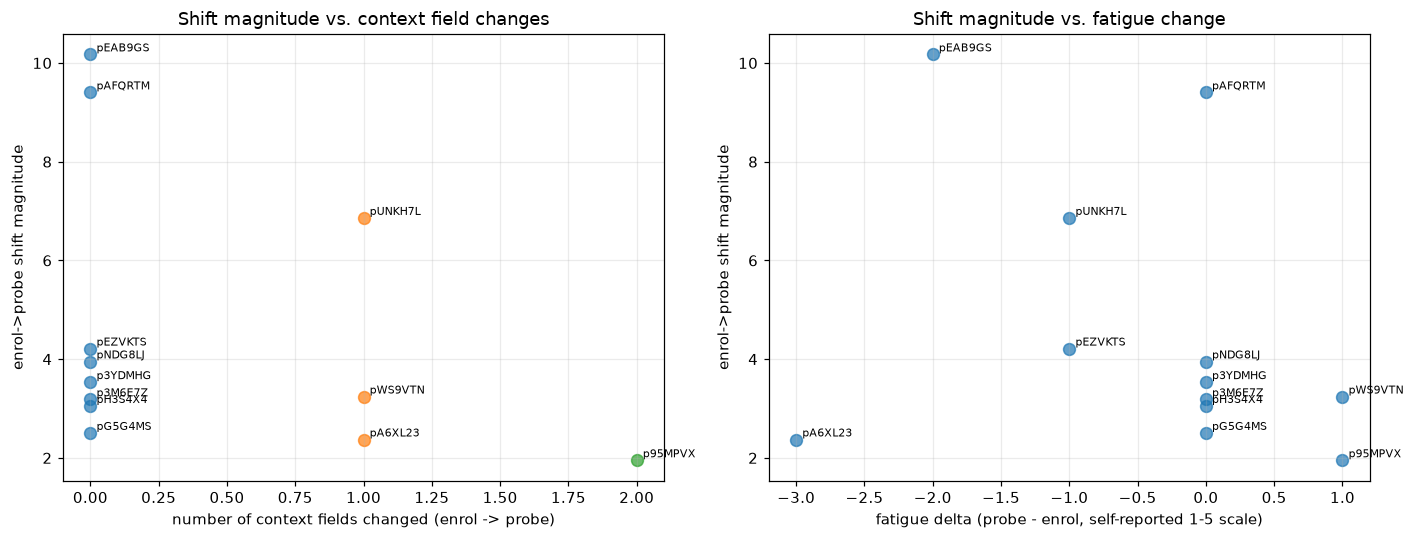

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sub = context_change_df.dropna(subset=['n_context_fields_changed', 'shift_magnitude'])
if len(sub):
    for n_changed, g in sub.groupby('n_context_fields_changed'):
        axes[0].scatter([n_changed]*len(g), g['shift_magnitude'], s=60, alpha=0.7)
        for _, r in g.iterrows():
            axes[0].annotate(r['participantId'], (n_changed, r['shift_magnitude']), fontsize=7,
                              xytext=(4, 2), textcoords='offset points')
    axes[0].set_xlabel('number of context fields changed (enrol -> probe)')
    axes[0].set_ylabel('enrol->probe shift magnitude')
    axes[0].set_title('Shift magnitude vs. context field changes')

sub2 = context_change_df.dropna(subset=['fatigue_delta', 'shift_magnitude'])
if len(sub2):
    axes[1].scatter(sub2['fatigue_delta'], sub2['shift_magnitude'], s=60, alpha=0.7)
    for _, r in sub2.iterrows():
        axes[1].annotate(r['participantId'], (r['fatigue_delta'], r['shift_magnitude']), fontsize=7,
                          xytext=(4, 2), textcoords='offset points')
    axes[1].set_xlabel('fatigue delta (probe - enrol, self-reported 1-5 scale)')
    axes[1].set_ylabel('enrol->probe shift magnitude')
    axes[1].set_title('Shift magnitude vs. fatigue change')

plt.tight_layout()
fig.savefig(PLOTS_DIR / '01_context_vs_shift.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Same check against verification AUC

In [6]:
if 'auc' in context_change_df.columns and context_change_df['auc'].notna().sum() >= 4:
    print(f"n = {context_change_df['auc'].notna().sum()} -- Spearman correlations with "
          f"verification AUC (small-N, descriptive only):\n")
    for col in ['handuse_changed', 'posture_changed', 'movement_changed', 'timeofday_changed',
                'n_context_fields_changed', 'fatigue_delta', 'focus_delta']:
        sub = context_change_df[[col, 'auc']].dropna()
        if len(sub) < 4 or sub[col].nunique() < 2:
            print(f"  {col:24s}: insufficient variation to correlate (n={len(sub)})")
            continue
        rho, p = stats.spearmanr(sub[col], sub['auc'])
        print(f"  {col:24s}: rho={rho:+.2f}, p={p:.3f}  (n={len(sub)})")
else:
    print("Not enough joined data to correlate -- check Section 2's warnings above.")


n = 12 -- Spearman correlations with verification AUC (small-N, descriptive only):

  handuse_changed         : insufficient variation to correlate (n=12)
  posture_changed         : rho=+0.21, p=0.517  (n=12)
  movement_changed        : rho=+0.21, p=0.517  (n=12)
  timeofday_changed       : rho=-0.03, p=0.918  (n=12)
  n_context_fields_changed: rho=+0.12, p=0.704  (n=12)
  fatigue_delta           : rho=+0.39, p=0.216  (n=12)
  focus_delta             : rho=+0.05, p=0.878  (n=12)


## 5. Conclusion for the dissertation

In [7]:
print("Context modelling summary:")
print("  - A learned, context-conditional fusion weighting scheme is NOT feasible with this")
print("    dataset: context and identity are almost perfectly confounded given ~1 probe session")
print("    per participant, leaving no within-person variation to learn a context effect from.")
print("  - This descriptive check asks whether context CHANGE (enrol vs probe) correlates with")
print("    known performance measures (shift magnitude, verification AUC) across the whole")
print(f"    evaluable cohort (n={len(context_change_df)}), rather than relying on the two")
print("    anecdotal cases already found (pAFQRTM's hand-use change, pUNKH7L's thin session).")
print("  - Any correlation reported above should be read as a small-N observation worth")
print("    mentioning in Discussion/Limitations, not a validated predictive relationship.")
print("  - Recommended framing: state the confound explicitly, report whichever context field")
print("    (if any) showed the clearest pattern above with its participant IDs named, and note")
print("    that a genuinely learnable context-weighting mechanism would require repeated")
print("    sessions per participant under deliberately varied conditions -- a data collection")
print("    design this project's dataset does not have, rather than a modelling limitation.")


Context modelling summary:
  - A learned, context-conditional fusion weighting scheme is NOT feasible with this
    dataset: context and identity are almost perfectly confounded given ~1 probe session
    per participant, leaving no within-person variation to learn a context effect from.
  - This descriptive check asks whether context CHANGE (enrol vs probe) correlates with
    known performance measures (shift magnitude, verification AUC) across the whole
    evaluable cohort (n=12), rather than relying on the two
    anecdotal cases already found (pAFQRTM's hand-use change, pUNKH7L's thin session).
  - Any correlation reported above should be read as a small-N observation worth
    mentioning in Discussion/Limitations, not a validated predictive relationship.
  - Recommended framing: state the confound explicitly, report whichever context field
    (if any) showed the clearest pattern above with its participant IDs named, and note
    that a genuinely learnable context-weighting mech

In [8]:
import json as _json
from datetime import datetime, timezone

manifest = {
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'n_evaluable_participants': len(context_change_df),
    'scope_note': 'descriptive correlation only -- learned context-conditional fusion weighting '
                   'is not feasible with this dataset (context/identity confound, ~1 probe session '
                   'per participant, no within-person variation to learn from)',
    'data': context_change_df.to_dict('records'),
}
with open(OUT_DIR / 'context_analysis_manifest.json', 'w') as f:
    _json.dump(manifest, f, indent=2, default=str)
print(f"Wrote outputs to {OUT_DIR.resolve()}")


Wrote outputs to /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/context_analysis


In [9]:
print(splits[splits['participantId']=='pAFQRTM'][['sessionId','sessionIndex','role']].to_string(index=False))
print()
print(sess_ctx[sess_ctx['participantId']=='pAFQRTM'][['sessionId','ctxHandUse']].to_string(index=False))

                       sessionId  sessionIndex  role
a34c77efa22646759b145b5c1f811d5f             1 train
a443b20adfc54b9790f4eb0289c3ec93             6 enrol
9da7a2a8da264c82ac68fbeb0336db8f             7 probe

                       sessionId       ctxHandUse
9da7a2a8da264c82ac68fbeb0336db8f       two_handed
a34c77efa22646759b145b5c1f811d5f one_handed_right
a443b20adfc54b9790f4eb0289c3ec93       two_handed
